# 실제 영상 연기 탐지 v3 — Cooldown + Hysteresis + ThinSmoke 지속성 개선

`assets/capture1.avi` 영상에 YOLOv8n-cls + ThinSmokeDetectorV2 + **3단계 연속성 개선**을 적용한다.

| 항목 | 내용 |
|---|---|
| 입력 영상 | `assets/capture1.avi` (640×480, 30fps, 약 4분 30초) |
| 모델 | `runs/smoke_detector/yolov8n_cls/weights/best.pt` |
| 출력 | 프레임별 오버레이 영상 + frame_log.csv + 타임라인 |

### v2 → v3 개선 요약 (thin_smoke_continuity_fix.md 반영)

| 문제 (v2) | 해결 (v3) | 단계 |
|---|---|---|
| 연기 구간에서 탐지 on/off 반복 | **Cooldown**: smoke 판정 후 최소 1.5초(45프레임) 강제 유지 | 1단계 |
| ThinSmoke persist 조건이 너무 까다로움 | **PERSIST_WINDOW 30f, 50% 조건**으로 완화 | 2단계 |
| 진입/해제 조건이 동일 → 경계선 flickering | **Hysteresis**: 해제는 30프레임 연속 3조건 충족 시만 허용 | 3단계 |

> **원칙: 오탐(FP) 허용, 미탐(FN) 불허**

## 0. 경로 및 파라미터 설정

In [1]:
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from collections import deque
from ultralytics import YOLO

# ── 경로 설정 ──────────────────────────────────────────────
BASE_DIR   = Path("..").resolve()
VIDEO_PATH = BASE_DIR / "assets" / "capture1.avi"
MODEL_PATH = BASE_DIR / "runs" / "smoke_detector" / "yolov8n_cls" / "weights" / "best.pt"
OUT_DIR    = BASE_DIR / "runs" / "smoke_detector" / "video_result_v3"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_VIDEO  = OUT_DIR / "capture1_result_v3.avi"
LOG_CSV    = OUT_DIR / "frame_log_v3.csv"

# ── 1단계: YOLO 탐지 파라미터 ────────────────────────────
SMOKE_THR   = 0.40  # raw confidence 임계값
VOTE_WINDOW = 5     # sliding vote 창 크기
VOTE_K      = 4     # [v3 조정] 5프레임 중 4개 이상이면 smoke 판정 (기존 3 → 4: 진입 조건 강화)

# ── 2단계: ThinSmoke v2 파라미터 ─────────────────────────
WARMUP_FRAMES       = 300  # 초기 베이스라인 워밍업 (10초)
BASELINE_WINDOW     = 300  # rolling percentile 창 크기
BASELINE_PCT        = 80   # 베이스라인 percentile (80th = 선명한 정상)
SHARP_SMOOTH_WINDOW = 30   # 선명도 rolling median 창 (1초)
SHARP_DROP_RATIO    = 0.50 # smooth_sharpness < 베이스라인 × 0.50
SAT_DROP_RATIO      = 0.82 # saturation < 베이스라인 × 0.82
YOLO_UNCERTAIN_LO   = 0.00 # 하한 없음 (실제 보호 = 이중 게이트)
YOLO_UNCERTAIN_HI   = 0.40 # YOLO가 확신(>0.40)이면 보조 탐지 불필요

# ── [v3] ThinSmoke 지속성 조건 완화 ─────────────────────
PERSIST_WINDOW = 30  # 지속성 확인 창 (v2: 15 → v3: 30)
PERSIST_THRESH = 15  # 30프레임 중 15개 이상 (50%) — 조건 완화

# ── [v3] Cooldown 파라미터 ───────────────────────────────
COOLDOWN_FRAMES = 15  # [v3 조정] 기존 45 → 15 (0.5초): 강제유지 축소로 과검출 억제

# ── [v3] Hysteresis 파라미터 ─────────────────────────────
EXIT_CONSECUTIVE = 5  # [v3 조정] 기존 15 → 5: 해제 조건 완화로 smoke_state 빠르게 해제

# ── [v3 신규] BalloonGate 파라미터 ───────────────────────
# 방법 1: 흰 볼록체(기구 등) 감지 → YOLO vote / ThinSmoke 억제
# 방법 2: 흰 물체 픽셀을 ThinSmoke 특징 계산에서 제외 (ROI 마스킹)
#
# 흰 기구 특성: V(밝기) ≈ 255, S(채도) ≈ 0, 원형/볼록 윤곽
# 연기 특성   : V 중간, S 낮음, 불규칙·확산 형태
WHITE_V_MIN          = 200   # 흰 물체 마스크: HSV Value 하한
WHITE_S_MAX          = 40    # 흰 물체 마스크: HSV Saturation 상한
BLOB_AREA_MIN        = 1000  # 유효 blob 최소 면적 (픽셀)
BLOB_CIRCULARITY_MIN = 0.45  # 원형도 하한 (연기≈0.1~0.3, 기구≈0.7~0.9)
BLOB_CONVEXITY_MIN   = 0.80  # 볼록도 하한 (기구의 볼록한 외형 반영)
# YOLO vote 억제 조건: balloon 감지 시 conf가 이 값 미만이면 YOLO 판정도 억제
# (conf가 매우 높으면 기구 옆에 실제 연기가 있을 가능성 → 억제하지 않음)
BALLOON_YOLO_SUPPRESS_THR = 0.65

# ── 영상 정보 및 모델 로드 ────────────────────────────────
cap          = cv2.VideoCapture(str(VIDEO_PATH))
TOTAL_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
FPS          = cap.get(cv2.CAP_PROP_FPS)
W            = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H            = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

print(f"입력 영상     : {VIDEO_PATH.name}")
print(f"해상도        : {W} x {H}  /  FPS: {FPS:.2f}  /  총 {TOTAL_FRAMES}프레임 ({TOTAL_FRAMES/FPS:.1f}초)")
print(f"ThinSmoke v2  : persist {PERSIST_THRESH}/{PERSIST_WINDOW}  |  Cooldown {COOLDOWN_FRAMES}f  |  Hysteresis exit {EXIT_CONSECUTIVE}f")
print(f"[BalloonGate] : V>{WHITE_V_MIN} & S<{WHITE_S_MAX}  |  area>{BLOB_AREA_MIN}px")
print(f"              : circularity>{BLOB_CIRCULARITY_MIN}  convexity>{BLOB_CONVEXITY_MIN}")
print(f"              : YOLO 억제 조건: balloon 감지 + conf < {BALLOON_YOLO_SUPPRESS_THR}")

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"best.pt 없음: {MODEL_PATH}\ntrain_yolo.ipynb 먼저 실행하세요.")

model     = YOLO(str(MODEL_PATH))
smoke_idx = [k for k, v in model.names.items() if v == "smoke"][0]
print(f"모델 로드     : {MODEL_PATH}")


입력 영상     : capture1.avi
해상도        : 640 x 480  /  FPS: 29.97  /  총 8097프레임 (270.2초)
ThinSmoke v2  : persist 15/30  |  Cooldown 15f  |  Hysteresis exit 5f
[BalloonGate] : V>200 & S<40  |  area>1000px
              : circularity>0.45  convexity>0.8
              : YOLO 억제 조건: balloon 감지 + conf < 0.65
모델 로드     : F:\일\Capstone_Project\AI_Capstone_Project\runs\smoke_detector\yolov8n_cls\weights\best.pt


## 0-1. ThinSmokeDetectorV2 클래스 정의

YOLO가 확신하지 못하는 구간(`conf < 0.40`)에서 영상 품질 지표로 얇은 연기를 보완 탐지한다.

```
탐지 조건 (모두 동시 만족):
  1. YOLO conf < 0.40 (YOLO가 아직 확신 없음)
  2. smooth_sharpness < baseline_80th × 0.50  (선명도 50% 이상 하락)
  3. saturation < baseline_80th × 0.82        (채도 18% 이상 하락)
  4. 위 두 조건이 30프레임 중 15프레임 이상 지속  ← [v3 완화]
```

In [2]:
def extract_features(frame: np.ndarray, exclude_mask: np.ndarray = None) -> tuple:
    """
    Laplacian Sharpness + HSV Saturation 추출.

    Args:
        frame       : BGR 프레임
        exclude_mask: [방법 2] 계산에서 제외할 픽셀 마스크 (255=제외, 0=포함)
                      흰 기구 영역을 마스킹하여 채도/선명도 왜곡 방지
    """
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    hsv  = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    if exclude_mask is not None and exclude_mask.any():
        valid = exclude_mask == 0  # True인 픽셀만 사용
        # Sharpness: Laplacian을 전체 이미지에서 계산 후 유효 픽셀 분산만 추출
        # (마스킹 후 계산하면 경계에 인위적 엣지 생겨 분산이 부풀려짐)
        lap       = cv2.Laplacian(gray, cv2.CV_64F)
        valid_lap = lap[valid]
        sharpness = float(np.var(valid_lap)) if valid_lap.size > 100 else 0.0
        # Saturation: 흰 물체 픽셀 제외 후 평균
        valid_sat = hsv[:, :, 1][valid]
        saturation = float(valid_sat.mean()) if valid_sat.size > 100 else 0.0
    else:
        sharpness  = float(cv2.Laplacian(gray, cv2.CV_64F).var())
        saturation = float(hsv[:, :, 1].mean())

    return sharpness, saturation


class BalloonGate:
    """
    [방법 1] 흰 볼록체(기구, 흰 물체 등) 감지 게이트.

    연기와 흰 기구의 핵심 차이:
      - 연기  : circularity 낮음(불규칙), convexity 낮음(확산)
      - 흰 기구: circularity 높음(원형),  convexity 높음(볼록)

    동작:
      1. HSV에서 흰 영역 마스크 생성 (V>WHITE_V_MIN, S<WHITE_S_MAX)
      2. Contour 추출 후 각 blob의 circularity + convexity 계산
      3. 조건 충족 blob 존재 시 is_balloon=True 반환
      4. 흰 영역 마스크(white_mask)를 ThinSmoke에 전달해 ROI 마스킹 수행
    """

    # morphological cleanup용 커널 (노이즈 제거)
    _kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

    def check(self, frame: np.ndarray) -> tuple:
        """
        Returns:
            is_balloon : 흰 볼록체 감지 여부
            white_mask : 흰 영역 마스크 (ROI 마스킹용)
            info       : 디버그 정보 dict
        """
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

        # 흰 영역 마스크: 매우 밝고(V>WHITE_V_MIN) 무채색(S<WHITE_S_MAX)
        white_mask = cv2.inRange(
            hsv,
            (0, 0, WHITE_V_MIN),
            (180, WHITE_S_MAX, 255)
        )
        # 모폴로지 오픈: 작은 노이즈 제거
        white_mask = cv2.morphologyEx(white_mask, cv2.MORPH_OPEN, self._kernel)

        info = {
            "white_ratio": float(white_mask.sum() / 255) / white_mask.size,
            "blob_count": 0,
            "max_area": 0,
            "max_circularity": 0.0,
            "max_convexity": 0.0,
        }

        contours, _ = cv2.findContours(
            white_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )

        is_balloon   = False
        best_circ    = 0.0
        best_conv    = 0.0
        valid_blobs  = 0
        max_area     = 0

        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < BLOB_AREA_MIN:
                continue  # 너무 작은 blob 무시

            valid_blobs += 1
            max_area = max(max_area, area)

            # 원형도 계산: 4π × area / perimeter² (완전한 원 = 1.0)
            perimeter = cv2.arcLength(cnt, True)
            if perimeter < 1.0:
                continue
            circularity = 4.0 * np.pi * area / (perimeter ** 2)

            # 볼록도 계산: contour면적 / convex hull면적 (볼록 = 1.0에 가까움)
            hull      = cv2.convexHull(cnt)
            hull_area = cv2.contourArea(hull)
            convexity = area / hull_area if hull_area > 1.0 else 0.0

            best_circ = max(best_circ, circularity)
            best_conv = max(best_conv, convexity)

            # 두 조건 모두 충족 → 흰 볼록 원형 물체 (기구 등)
            if circularity >= BLOB_CIRCULARITY_MIN and convexity >= BLOB_CONVEXITY_MIN:
                is_balloon = True

        info.update({
            "blob_count"      : valid_blobs,
            "max_area"        : max_area,
            "max_circularity" : round(best_circ, 3),
            "max_convexity"   : round(best_conv, 3),
        })
        return is_balloon, white_mask, info


class RollingPercentileBaseline:
    """
    최근 N프레임의 P번째 percentile을 베이스라인으로 사용.
    """
    def __init__(self, window: int = 300, percentile: int = 80):
        self.buf        = deque(maxlen=window)
        self.percentile = percentile

    def update(self, value: float):
        self.buf.append(value)

    def get_baseline(self):
        if len(self.buf) < (self.buf.maxlen or 1) // 2:
            return None
        return float(np.percentile(list(self.buf), self.percentile))


class ThinSmokeDetectorV2:
    """
    v3 변경사항:
    - PERSIST_WINDOW: 15 → 30, PERSIST_THRESH: 80% → 50%
    - BalloonGate 결과 수신: 기구 감지 시 조기 종료 + ROI 마스킹 적용
    """
    def __init__(self):
        self.sharp_baseline   = RollingPercentileBaseline(BASELINE_WINDOW, BASELINE_PCT)
        self.sat_baseline     = RollingPercentileBaseline(BASELINE_WINDOW, BASELINE_PCT)
        self.persist_buf      = deque(maxlen=PERSIST_WINDOW)
        self.sharp_smooth_buf = deque(maxlen=SHARP_SMOOTH_WINDOW)
        self.frame_count      = 0

    def update(
        self,
        frame: np.ndarray,
        yolo_conf: float,
        white_mask: np.ndarray = None,
        is_balloon: bool = False,
    ) -> tuple:
        """
        Args:
            frame      : BGR 프레임
            yolo_conf  : YOLO smoke confidence
            white_mask : BalloonGate의 흰 영역 마스크 (ROI 마스킹용)
            is_balloon : BalloonGate가 흰 볼록체를 감지했으면 True
        """
        self.frame_count += 1

        # [방법 2] ROI 마스킹: 흰 물체 영역 제외 후 특징 계산
        # 기구가 없는 경우에도 흰 영역을 제외하여 통계 왜곡 방지
        sharpness, saturation = extract_features(frame, exclude_mask=white_mask)

        self.sharp_smooth_buf.append(sharpness)
        self.sharp_baseline.update(sharpness)
        self.sat_baseline.update(saturation)

        smooth_sharpness = float(np.median(list(self.sharp_smooth_buf)))

        info = {
            "sharpness": smooth_sharpness,
            "saturation": saturation,
            "sharp_base": None, "sat_base": None,
            "sharp_ratio": None, "sat_ratio": None,
            "both_low": False, "persist_cnt": 0,
            "suppressed_by_gate": is_balloon,
        }

        # 워밍업 중에는 탐지 비활성
        if self.frame_count < WARMUP_FRAMES:
            self.persist_buf.append(0)
            return False, info

        # [방법 1] BalloonGate 발동 시 ThinSmoke 탐지 억제
        # 흰 기구가 감지된 프레임: 채도/선명도 하락이 기구에 의한 것일 수 있음
        if is_balloon:
            self.persist_buf.append(0)  # persist 버퍼에 0 추가 (연기 없음으로 처리)
            return False, info

        # YOLO가 이미 smoke에 확신 → 보조 탐지 불필요
        if not (YOLO_UNCERTAIN_LO <= yolo_conf <= YOLO_UNCERTAIN_HI):
            self.persist_buf.append(0)
            return False, info

        sharp_base = self.sharp_baseline.get_baseline()
        sat_base   = self.sat_baseline.get_baseline()
        if sharp_base is None or sat_base is None or sharp_base < 1.0 or sat_base < 1.0:
            self.persist_buf.append(0)
            return False, info

        sharp_ratio = smooth_sharpness / sharp_base
        sat_ratio   = saturation / sat_base
        both_low    = (sharp_ratio < SHARP_DROP_RATIO) and (sat_ratio < SAT_DROP_RATIO)

        info.update({
            "sharp_base": sharp_base, "sat_base": sat_base,
            "sharp_ratio": sharp_ratio, "sat_ratio": sat_ratio,
            "both_low": both_low,
        })

        self.persist_buf.append(1 if both_low else 0)
        persist_cnt         = sum(self.persist_buf)
        info["persist_cnt"] = persist_cnt

        thin_smoke = (len(self.persist_buf) == PERSIST_WINDOW and persist_cnt >= PERSIST_THRESH)
        return thin_smoke, info


def draw_overlay_v3(frame, final_label, yolo_raw, yolo_conf, vote_cnt,
                    thin_smoke, thin_info, smoke_state, cooldown_counter,
                    is_balloon, gate_info, frame_idx, total, elapsed):
    """상단 바에 최종 판정 + YOLO + ThinSmoke + BalloonGate 상태 표시."""
    h, w      = frame.shape[:2]
    is_smoke  = (final_label == "smoke")
    is_thin   = thin_smoke and not (yolo_conf >= SMOKE_THR)
    is_cd     = (not smoke_state) and (cooldown_counter > 0)
    bar_color = (0, 0, 200) if is_smoke else (0, 180, 0)
    if is_balloon:
        bar_color = (0, 140, 255)  # 주황색: balloon gate 활성

    cv2.rectangle(frame, (0, 0), (w, 100), bar_color, -1)

    tag = "[SMOKE]"
    if not is_smoke:
        tag = "[NO SMOKE]"
    elif is_cd:
        tag += " (cooldown)"
    elif is_thin:
        tag += " (thin)"
    if is_balloon:
        tag += " [BALLOON GATE]"

    cv2.putText(frame, f"{tag}  vote={vote_cnt}/{VOTE_WINDOW}",
                (10, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)
    cv2.putText(frame, f"YOLO: {yolo_conf:.2f} ({yolo_raw})",
                (10, 44), cv2.FONT_HERSHEY_SIMPLEX, 0.48, (220, 220, 220), 1, cv2.LINE_AA)

    if thin_info["sharp_ratio"] is not None:
        thin_txt = (f"ThinSmoke: sharp_r={thin_info['sharp_ratio']:.2f} "
                    f"sat_r={thin_info['sat_ratio']:.2f} "
                    f"persist={thin_info['persist_cnt']}/{PERSIST_WINDOW}")
    else:
        thin_txt = f"ThinSmoke: warmup... ({max(0, WARMUP_FRAMES - frame_idx)}f left)"
    cv2.putText(frame, thin_txt, (10, 64),
                cv2.FONT_HERSHEY_SIMPLEX, 0.40, (200, 230, 255), 1, cv2.LINE_AA)

    # BalloonGate 상태 표시
    gate_txt = (
        f"BalloonGate: {'ON' if is_balloon else 'off'}"
        f"  circ={gate_info['max_circularity']:.2f}"
        f"  conv={gate_info['max_convexity']:.2f}"
        f"  area={gate_info['max_area']}px"
    )
    cv2.putText(frame, gate_txt, (10, 82),
                cv2.FONT_HERSHEY_SIMPLEX, 0.38, (80, 255, 255), 1, cv2.LINE_AA)

    cd_txt = f"CD:{cooldown_counter:3d}f  Hyst:{'SMOKE' if smoke_state else 'CLEAR'}"
    cv2.putText(frame, cd_txt, (10, 97),
                cv2.FONT_HERSHEY_SIMPLEX, 0.35, (255, 255, 180), 1, cv2.LINE_AA)

    cv2.putText(frame, f"Frame {frame_idx}/{total}  {elapsed:.1f}s",
                (w - 270, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)
    return frame


print("클래스 정의 완료: BalloonGate / extract_features(ROI마스킹) / ThinSmokeDetectorV2 / draw_overlay_v3")
print(f"[BalloonGate] 조건: circ>={BLOB_CIRCULARITY_MIN}, conv>={BLOB_CONVEXITY_MIN}, area>={BLOB_AREA_MIN}px")


클래스 정의 완료: BalloonGate / extract_features(ROI마스킹) / ThinSmokeDetectorV2 / draw_overlay_v3
[BalloonGate] 조건: circ>=0.45, conv>=0.8, area>=1000px


## 1. 영상 전체 추론 → 결과 영상 저장

**v3 추론 파이프라인** (순서 중요):

```
① YOLO 추론
② Sliding window vote (YOLO)
③ BalloonGate: 흰 볼록체 감지 → white_mask 생성 [방법 1]
   └ is_balloon=True이면 YOLO vote 억제 (conf < 0.65 조건)
④ ThinSmoke v2: white_mask로 ROI 마스킹 후 특징 계산 [방법 2]
   └ is_balloon=True이면 thin_smoke 즉시 억제
⑤ Hysteresis 판정 (raw_smoke=False 15프레임 연속 시 해제)
⑥ Cooldown (smoke_state 기준 최소 45프레임 강제 유지)
⑦ 오버레이 저장 + CSV 로그
```

> 오버레이 색상: 빨간=smoke / 초록=no_smoke / **주황=BalloonGate 활성**

In [3]:
cap_read = cv2.VideoCapture(str(VIDEO_PATH))
writer   = cv2.VideoWriter(str(OUT_VIDEO), cv2.VideoWriter_fourcc(*"XVID"), FPS, (W, H))
vote_buf = deque(maxlen=VOTE_WINDOW)
detector = ThinSmokeDetectorV2()
gate     = BalloonGate()

# ── 상태 변수 초기화 ─────────────────────────────────────
cooldown_counter       = 0
cooldown_forced_count  = 0
smoke_state            = False
clear_streak           = 0
hysteresis_held_count  = 0

# 통계 카운터
yolo_smoke_cnt   = 0
thin_smoke_cnt   = 0
thin_raw_cnt     = 0
final_smoke_cnt  = 0
balloon_cnt      = 0   # BalloonGate 발동 프레임 수
balloon_suppress = 0   # BalloonGate로 억제된 smoke 판정 수
frame_idx        = 0
ms_list          = []
start_wall       = time.perf_counter()

with open(LOG_CSV, "w", encoding="utf-8") as f:
    f.write("frame,sec,yolo_conf,yolo_raw,thin_smoke,balloon_gate,smoke_state,"
            "cooldown,final,sharp,sat,sharp_ratio,sat_ratio,persist,"
            "blob_circ,blob_conv,blob_area\n")

print("추론 시작 (v3 + BalloonGate)...")
while True:
    ret, frame = cap_read.read()
    if not ret:
        break
    frame_idx += 1

    # ① YOLO 추론
    t0      = time.perf_counter()
    results = model.predict(frame, verbose=False, imgsz=224)
    ms_list.append((time.perf_counter() - t0) * 1000)

    yolo_conf = float(results[0].probs.data[smoke_idx])
    yolo_raw  = "smoke" if yolo_conf >= SMOKE_THR else "no_smoke"

    # ② Sliding window vote
    vote_buf.append(1 if yolo_raw == "smoke" else 0)
    vote_cnt  = sum(vote_buf)
    yolo_vote = vote_cnt >= VOTE_K

    # ③ BalloonGate: 흰 볼록체 감지 [방법 1]
    is_balloon, white_mask, gate_info = gate.check(frame)
    if is_balloon:
        balloon_cnt += 1
        # YOLO vote 억제: balloon 감지 + conf가 충분히 높지 않으면
        # (conf >= BALLOON_YOLO_SUPPRESS_THR이면 기구 옆 실제 연기일 수 있어 유지)
        if yolo_vote and yolo_conf < BALLOON_YOLO_SUPPRESS_THR:
            yolo_vote = False
            balloon_suppress += 1

    if yolo_vote:
        yolo_smoke_cnt += 1

    # ④ ThinSmoke v2: ROI 마스킹 적용 후 특징 계산 [방법 2]
    # white_mask를 전달해 흰 영역 픽셀을 채도/선명도 계산에서 제외
    thin_smoke, thin_info = detector.update(frame, yolo_conf, white_mask, is_balloon)
    if thin_smoke:
        thin_raw_cnt += 1

    # ⑤ Hysteresis 판정
    raw_smoke = yolo_vote or thin_smoke

    if not smoke_state:
        if raw_smoke and frame_idx >= WARMUP_FRAMES:
            smoke_state  = True
            clear_streak = 0
    else:
        if not raw_smoke:
            clear_streak += 1
            if clear_streak >= EXIT_CONSECUTIVE:
                smoke_state  = False
                clear_streak = 0
        else:
            if clear_streak > 0:
                hysteresis_held_count += clear_streak
            clear_streak = 0

    # ⑥ Cooldown
    final_smoke = smoke_state
    if final_smoke:
        cooldown_counter = COOLDOWN_FRAMES
    elif cooldown_counter > 0:
        final_smoke      = True
        cooldown_counter -= 1
        cooldown_forced_count += 1

    if final_smoke:
        final_smoke_cnt += 1
    if thin_smoke and not yolo_vote:
        thin_smoke_cnt += 1
    final_label = "smoke" if final_smoke else "no_smoke"

    # ⑦ 오버레이 저장
    elapsed   = time.perf_counter() - start_wall
    out_frame = draw_overlay_v3(
        frame.copy(), final_label, yolo_raw, yolo_conf, vote_cnt,
        thin_smoke, thin_info, smoke_state, cooldown_counter,
        is_balloon, gate_info, frame_idx, TOTAL_FRAMES, elapsed
    )
    writer.write(out_frame)

    # CSV 로그 (balloon 컬럼 추가)
    with open(LOG_CSV, "a", encoding="utf-8") as f:
        sec = frame_idx / FPS
        sr  = f"{thin_info['sharp_ratio']:.3f}" if thin_info["sharp_ratio"] is not None else ""
        sar = f"{thin_info['sat_ratio']:.3f}"   if thin_info["sat_ratio"]   is not None else ""
        f.write(
            f"{frame_idx},{sec:.2f},{yolo_conf:.4f},{yolo_raw},"
            f"{int(thin_smoke)},{int(is_balloon)},{int(smoke_state)},"
            f"{cooldown_counter},{final_label},"
            f"{thin_info['sharpness']:.1f},{thin_info['saturation']:.2f},"
            f"{sr},{sar},{thin_info['persist_cnt']},"
            f"{gate_info['max_circularity']},{gate_info['max_convexity']},{gate_info['max_area']}\n"
        )

    if frame_idx % 500 == 0 or frame_idx == TOTAL_FRAMES:
        pct    = frame_idx / TOTAL_FRAMES * 100
        avg_ms = np.mean(ms_list[-500:])
        print(
            f"  [{pct:5.1f}%] {frame_idx}/{TOTAL_FRAMES}  "
            f"avg {avg_ms:.1f}ms  "
            f"YOLO={yolo_smoke_cnt}({yolo_smoke_cnt/frame_idx*100:.1f}%)  "
            f"Balloon={balloon_cnt}({balloon_cnt/frame_idx*100:.1f}%)  "
            f"Final={final_smoke_cnt}({final_smoke_cnt/frame_idx*100:.1f}%)"
        )

cap_read.release()
writer.release()

total_sec = time.perf_counter() - start_wall
total     = max(frame_idx, 1)

print("\n" + "=" * 65)
print(f"  처리 프레임         : {frame_idx}장  ({total_sec:.1f}초)")
print(f"  평균 속도           : {np.mean(ms_list):.1f} ms/frame  ({1000/np.mean(ms_list):.1f} FPS)")
print(f"  YOLO smoke          : {yolo_smoke_cnt}장 ({yolo_smoke_cnt/total*100:.1f}%)")
print(f"  ThinSmoke 발화      : {thin_raw_cnt}장 ({thin_raw_cnt/total*100:.1f}%)")
print(f"  ThinSmoke 추가      : {thin_smoke_cnt}장 ({thin_smoke_cnt/total*100:.1f}%)  <- 보조 탐지만")
print(f"  최종 smoke          : {final_smoke_cnt}장 ({final_smoke_cnt/total*100:.1f}%)")
print(f"  [BalloonGate] 발동  : {balloon_cnt}장 ({balloon_cnt/total*100:.1f}%)")
print(f"  [BalloonGate] YOLO억제: {balloon_suppress}장")
print(f"  [Cooldown] 강제유지 : {cooldown_forced_count}프레임")
print(f"  저장 영상           : {OUT_VIDEO}")
print(f"  프레임 로그         : {LOG_CSV}")
print("=" * 65)


추론 시작 (v3 + BalloonGate)...
  [  6.2%] 500/8097  avg 3.9ms  YOLO=39(7.8%)  Balloon=38(7.6%)  Final=79(15.8%)
  [ 12.4%] 1000/8097  avg 3.3ms  YOLO=41(4.1%)  Balloon=40(4.0%)  Final=143(14.3%)
  [ 18.5%] 1500/8097  avg 3.3ms  YOLO=220(14.7%)  Balloon=45(3.0%)  Final=476(31.7%)
  [ 24.7%] 2000/8097  avg 3.4ms  YOLO=305(15.2%)  Balloon=71(3.5%)  Final=746(37.3%)
  [ 30.9%] 2500/8097  avg 3.6ms  YOLO=380(15.2%)  Balloon=110(4.4%)  Final=900(36.0%)
  [ 37.1%] 3000/8097  avg 3.9ms  YOLO=383(12.8%)  Balloon=159(5.3%)  Final=923(30.8%)
  [ 43.2%] 3500/8097  avg 3.9ms  YOLO=402(11.5%)  Balloon=159(4.5%)  Final=1018(29.1%)
  [ 49.4%] 4000/8097  avg 4.0ms  YOLO=489(12.2%)  Balloon=159(4.0%)  Final=1275(31.9%)
  [ 55.6%] 4500/8097  avg 4.0ms  YOLO=511(11.4%)  Balloon=159(3.5%)  Final=1362(30.3%)
  [ 61.8%] 5000/8097  avg 3.9ms  YOLO=674(13.5%)  Balloon=159(3.2%)  Final=1594(31.9%)
  [ 67.9%] 5500/8097  avg 3.6ms  YOLO=1064(19.3%)  Balloon=159(2.9%)  Final=2002(36.4%)
  [ 74.1%] 6000/8097  avg 3.8m

## 2. 시간대별 smoke 탐지 타임라인

YOLO 기여분(파란색), ThinSmoke 보조 탐지(주황색), Cooldown/Hysteresis 강제 유지(초록색)를 구분하여 시각화한다.

C:\Users\User\AppData\Local\Temp\ipykernel_2592\1183582459.py:50: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_2592\1183582459.py:50: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_2592\1183582459.py:50: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_2592\1183582459.py:50: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_2592\1183582459.py:50: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_2592\1183582459.py:50: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) De

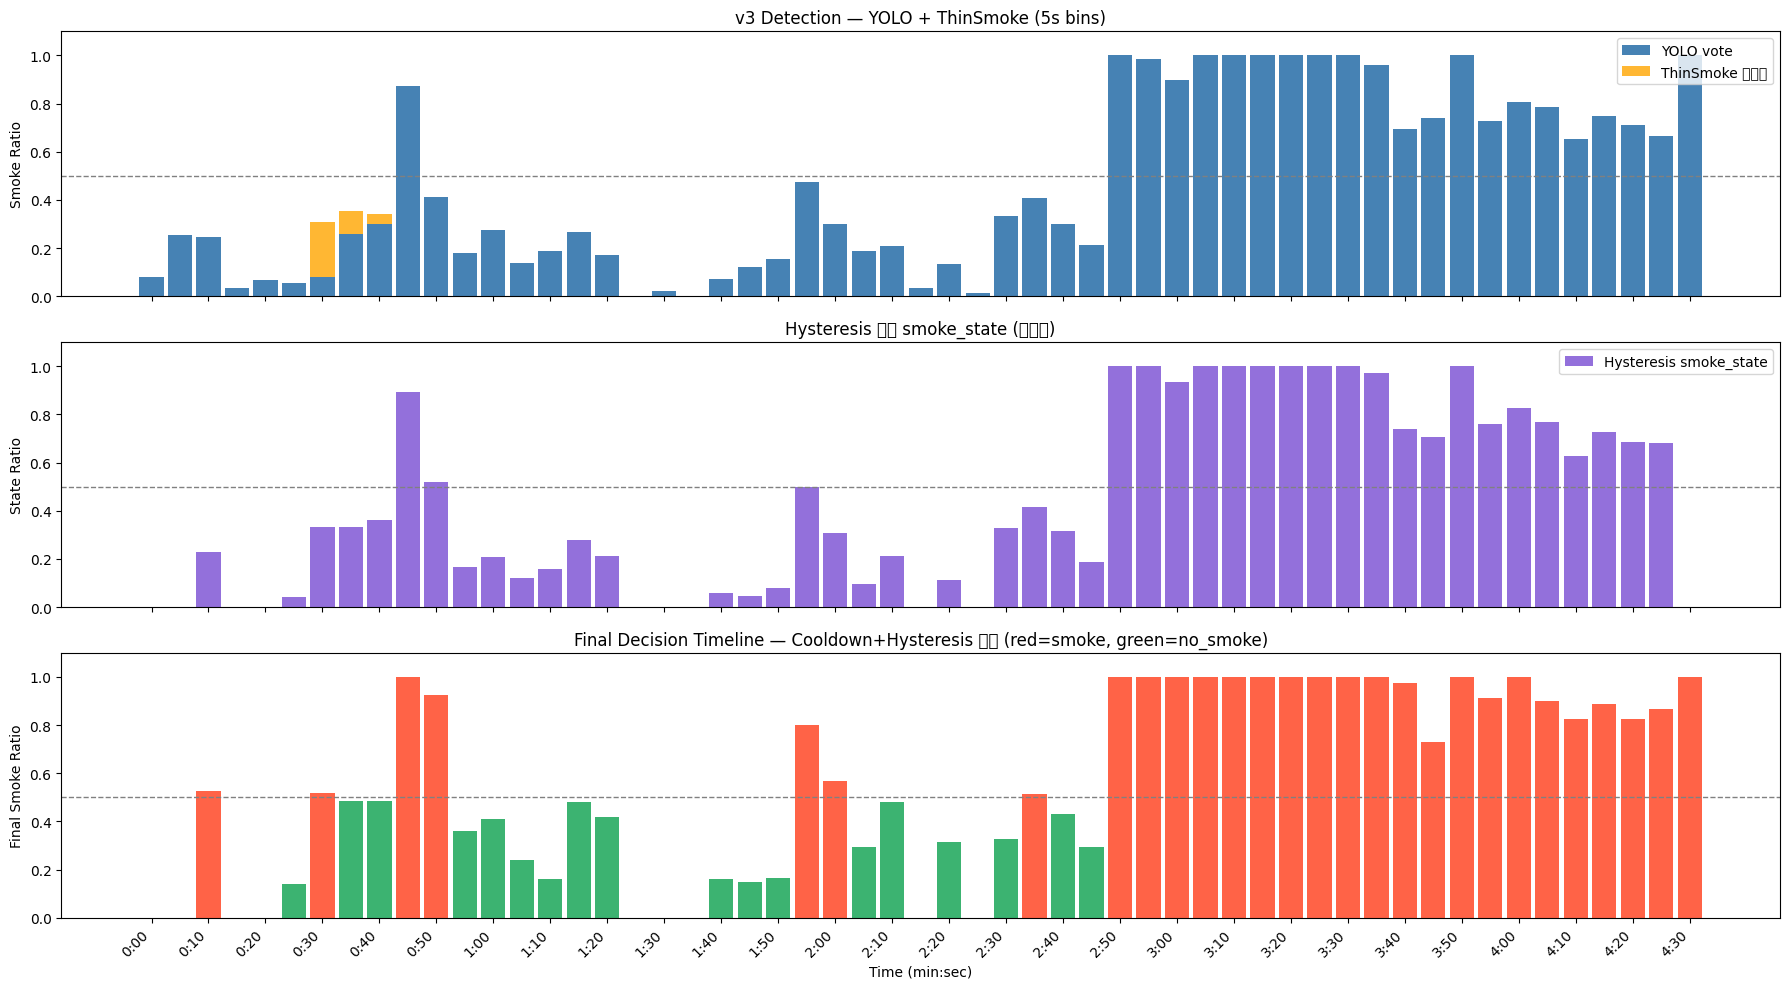

타임라인 저장: F:\일\Capstone_Project\AI_Capstone_Project\runs\smoke_detector\video_result_v3\smoke_timeline_v3.png


In [4]:
df      = pd.read_csv(LOG_CSV)
bin_sec = 5

df["bin"] = (df["sec"] // bin_sec).astype(int)
timeline  = df.groupby("bin").agg(
    yolo_ratio   = ("yolo_raw",    lambda x: (x == "smoke").mean()),
    final_ratio  = ("final",       lambda x: (x == "smoke").mean()),
    thin_ratio   = ("thin_smoke",  "mean"),
    state_ratio  = ("smoke_state", "mean"),  # hysteresis 확정 smoke
    cd_ratio     = ("cooldown",    lambda x: (x > 0).mean()),  # cooldown 활성 비율
).reset_index()

n_bins   = len(timeline)
x_labels = [f"{int(b*bin_sec)//60}:{int(b*bin_sec)%60:02d}" for b in timeline["bin"]]

fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=True)

# 상단: YOLO + ThinSmoke 기여 분리
axes[0].bar(range(n_bins), timeline["yolo_ratio"],  color="steelblue", width=0.85, label="YOLO vote")
axes[0].bar(range(n_bins), timeline["thin_ratio"],  bottom=timeline["yolo_ratio"],
            color="orange", width=0.85, alpha=0.8,  label="ThinSmoke 추가분")
axes[0].axhline(0.5, color="gray", ls="--", lw=1)
axes[0].set_ylabel("Smoke Ratio")
axes[0].set_title("v3 Detection — YOLO + ThinSmoke (5s bins)")
axes[0].set_ylim(0, 1.1)
axes[0].legend(loc="upper right")

# 중단: Hysteresis smoke_state
axes[1].bar(range(n_bins), timeline["state_ratio"], color="mediumpurple", width=0.85, label="Hysteresis smoke_state")
axes[1].axhline(0.5, color="gray", ls="--", lw=1)
axes[1].set_ylabel("State Ratio")
axes[1].set_title("Hysteresis 확정 smoke_state (보라색)")
axes[1].set_ylim(0, 1.1)
axes[1].legend(loc="upper right")

# 하단: 최종 판정 (Cooldown 포함)
colors = ["tomato" if r >= 0.5 else "mediumseagreen" for r in timeline["final_ratio"]]
axes[2].bar(range(n_bins), timeline["final_ratio"], color=colors, width=0.85)
axes[2].axhline(0.5, color="gray", ls="--", lw=1)
axes[2].set_ylabel("Final Smoke Ratio")
axes[2].set_title("Final Decision Timeline — Cooldown+Hysteresis 적용 (red=smoke, green=no_smoke)")
axes[2].set_ylim(0, 1.1)
axes[2].set_xticks(range(0, n_bins, max(1, n_bins // 20)))
axes[2].set_xticklabels(
    [x_labels[i] for i in range(0, n_bins, max(1, n_bins // 20))],
    rotation=45, ha="right"
)
axes[2].set_xlabel("Time (min:sec)")

plt.tight_layout()
timeline_path = OUT_DIR / "smoke_timeline_v3.png"
plt.savefig(str(timeline_path), dpi=150)
plt.show()
print(f"타임라인 저장: {timeline_path}")

## 3. ThinSmoke 탐지 구간 상세 분석

ThinSmoke가 발화한 프레임과 그 전후 문맥을 확인한다.

In [5]:
thin_only = df[(df["thin_smoke"] == 1) & (df["yolo_raw"] == "no_smoke")]

print(f"ThinSmoke 보조 탐지 프레임 수: {len(thin_only)}장")
print(f"FP 검증 (0~30초 구간 오탐): {len(df[(df['sec'] <= 30) & (df['thin_smoke'] == 1)])}건  ← 0이어야 함")
print()

if len(thin_only) > 0:
    print("[ThinSmoke 발화 구간]")
    print(thin_only[["sec", "yolo_conf", "sharp_ratio", "sat_ratio", "persist"]].to_string(index=False))

ThinSmoke 보조 탐지 프레임 수: 54장
FP 검증 (0~30초 구간 오탐): 0건  ← 0이어야 함

[ThinSmoke 발화 구간]
  sec  yolo_conf  sharp_ratio  sat_ratio  persist
31.33     0.0988        0.350      0.711       15
31.36     0.2195        0.350      0.703       16
31.40     0.3045        0.351      0.702       17
31.43     0.2838        0.360      0.709       18
31.46     0.1895        0.363      0.726       19
31.50     0.2881        0.356      0.745       20
31.53     0.2697        0.347      0.763       21
31.56     0.3180        0.340      0.776       22
31.60     0.2887        0.336      0.787       23
31.73     0.3926        0.272      0.829       23
31.77     0.3354        0.266      0.831       23
31.80     0.3735        0.266      0.838       23
31.83     0.2465        0.259      0.843       23
31.87     0.3021        0.244      0.845       22
31.90     0.2934        0.233      0.858       21
31.93     0.3944        0.226      0.864       20
31.97     0.2823        0.219      0.854       19
32.00     0.2950    

## 4. 연속성 개선 효과 검증

thin_smoke_continuity_fix.md 검증 항목을 확인한다.

C:\Users\User\AppData\Local\Temp\ipykernel_2592\2623284103.py:60: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_2592\2623284103.py:60: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_2592\2623284103.py:60: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_2592\2623284103.py:60: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_2592\2623284103.py:60: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_2592\2623284103.py:60: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) Deja

  [v3 검증 결과] thin_smoke_continuity_fix.md 기준
  ① 0~30초 오탐 수       : 100건  (목표: 0건)  ✗ FAIL
  ② smoke 구간 평균 연속 : 114.1프레임  (길수록 연속성 ↑)
     smoke 구간 내 끊김  : 평균 74.5f / 최대 518f  (짧을수록 연속성 ↑)
  ③ ThinSmoke 발화 수    : 54프레임  (v2: 30장, 증가 예상)
  ④ 최종 smoke 비율      : 54.8%  (v2: 44.5%, 소폭 증가 허용)

  [v3 신규] Cooldown 강제  : 850프레임
  [v3 신규] Hysteresis 유지: 87프레임



c:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **k

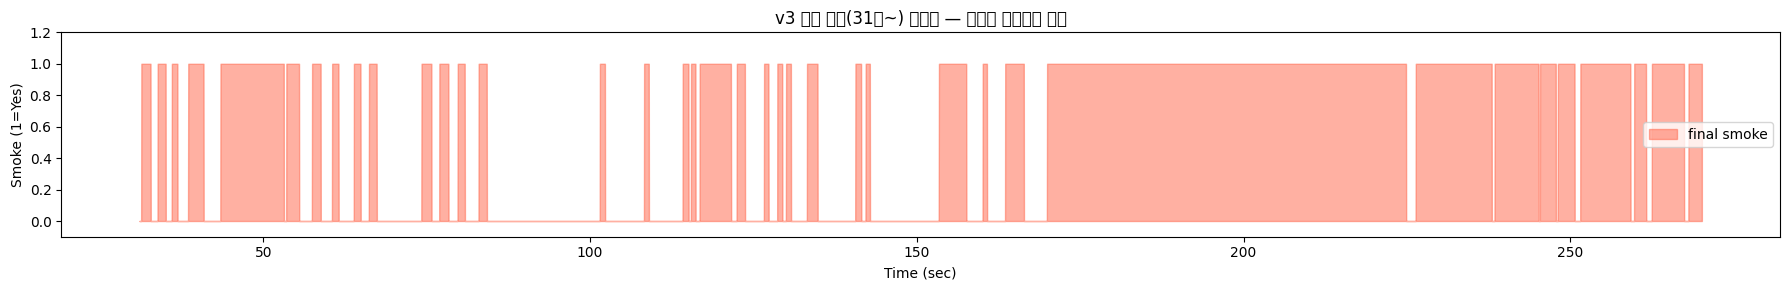

연속성 그래프 저장: F:\일\Capstone_Project\AI_Capstone_Project\runs\smoke_detector\video_result_v3\smoke_continuity_v3.png


In [6]:
# ── 검증 항목 1: 0~30초 구간 오탐 수 ─────────────────────
fp_count = len(df[(df["sec"] <= 30) & (df["final"] == "smoke")])

# ── 검증 항목 2: 얇은 연기 구간(31초~) 연속성 분석 ───────
smoke_after_31 = df[df["sec"] > 31].copy()
smoke_after_31["is_smoke"] = (smoke_after_31["final"] == "smoke").astype(int)

# 연속 탐지 구간(run) 분석
def find_runs(series):
    """True/False 시퀀스에서 연속 구간 길이 목록 반환"""
    runs = []
    if len(series) == 0:
        return runs
    current_val = series.iloc[0]
    current_len = 1
    for v in series.iloc[1:]:
        if v == current_val:
            current_len += 1
        else:
            runs.append((current_val, current_len))
            current_val = v
            current_len = 1
    runs.append((current_val, current_len))
    return runs

runs    = find_runs(smoke_after_31["is_smoke"])
# smoke 구간 중 끊김(no_smoke) 길이
gaps    = [length for val, length in runs if val == 0]
smokes  = [length for val, length in runs if val == 1]

# ── 검증 항목 3: ThinSmoke 발화 프레임 수 ────────────────
thin_count_total = len(df[df["thin_smoke"] == 1])

# ── 검증 항목 4: 최종 smoke 비율 ─────────────────────────
final_smoke_ratio = (df["final"] == "smoke").mean() * 100

print("=" * 55)
print("  [v3 검증 결과] thin_smoke_continuity_fix.md 기준")
print("=" * 55)
print(f"  ① 0~30초 오탐 수       : {fp_count}건  (목표: 0건)  {'✓ PASS' if fp_count == 0 else '✗ FAIL'}")
print(f"  ② smoke 구간 평균 연속 : {np.mean(smokes):.1f}프레임  (길수록 연속성 ↑)")
print(f"     smoke 구간 내 끊김  : 평균 {np.mean(gaps):.1f}f / 최대 {max(gaps) if gaps else 0}f  (짧을수록 연속성 ↑)")
print(f"  ③ ThinSmoke 발화 수    : {thin_count_total}프레임  (v2: 30장, 증가 예상)")
print(f"  ④ 최종 smoke 비율      : {final_smoke_ratio:.1f}%  (v2: 44.5%, 소폭 증가 허용)")
print()
print(f"  [v3 신규] Cooldown 강제  : {cooldown_forced_count}프레임")
print(f"  [v3 신규] Hysteresis 유지: {hysteresis_held_count}프레임")
print()

# ── smoke 구간 탐지 끊김 시각화 ──────────────────────────
fig, ax = plt.subplots(figsize=(18, 3))
ax.fill_between(smoke_after_31["sec"], smoke_after_31["is_smoke"],
                alpha=0.5, color="tomato", label="final smoke")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Smoke (1=Yes)")
ax.set_title("v3 연기 구간(31초~) 연속성 — 끊김이 없을수록 개선")
ax.set_ylim(-0.1, 1.2)
ax.legend()
continuity_path = OUT_DIR / "smoke_continuity_v3.png"
plt.tight_layout()
plt.savefig(str(continuity_path), dpi=150)
plt.show()
print(f"연속성 그래프 저장: {continuity_path}")